Simulation complete.
MDE (approx) at alpha=0.05, 80% power: 3.324%


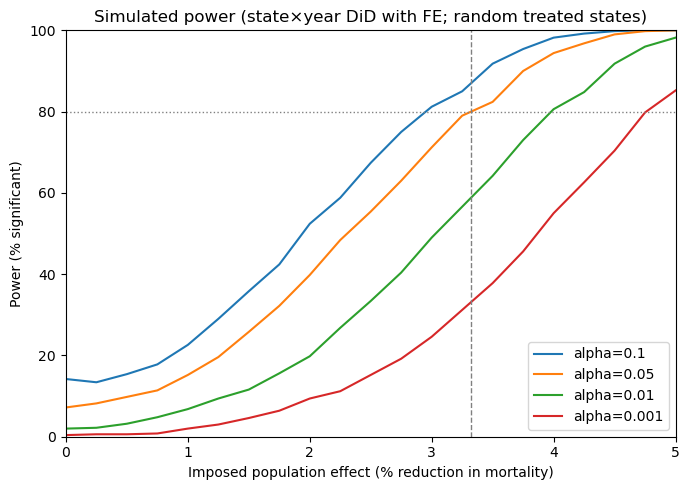

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import t
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# ----------------------------
# 0) CONFIG
# ----------------------------
DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"   # change to your path
MAX_DATASET_NUMBER = 500

NUMBER_POST_YEARS = 3
LAST_YEAR = 2013 - NUMBER_POST_YEARS + 1   # 2011
NUMBER_PRE_YEARS = 5
FIRST_YEAR = LAST_YEAR - NUMBER_PRE_YEARS  # 2006

STEP_SIZE = 0.0025
END_VALUE = 0.05
EFFECT_GRID = np.round(np.arange(0, END_VALUE + 1e-12, STEP_SIZE), 10)  # in [0,1]

ALPHAS = [0.10, 0.05, 0.01, 0.001]  # significance levels

# ----------------------------
# 1) LOAD + CLEAN WONDER DATA
# ----------------------------
df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Drop totals and any rows without year
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.loc[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

# Drop notes column if present (not needed)
if "notes" in df.columns:
    pass

# Keep years needed for the pseudo design (script also drops year>=2014 and year<first_year)
df = df.loc[(df["year"] < 2014) & (df["year"] >= FIRST_YEAR)].copy()

# Make sure deaths/pop are numeric
df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

# State identifier: use state_code (numeric) as entity id
# (Stata uses statecode; you have state_code)
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# ----------------------------
# 2) DEFINE "NUMBER_EXPAND" (how many treated states per simulation)
# ----------------------------
# The Stata example computes number_expand from a hand-coded "full expansion" list.
# But that is ONLY used to decide how many states are pseudo-treated each simulation.
# To keep it simple and match the README text ("23 treated vs 18 control"), set:
NUMBER_EXPAND = 23

# If you want instead to mimic Stata’s internal count, replace the line above with
# NUMBER_EXPAND = 16 or compute it from some classification list.

# ----------------------------
# 3) HELPER: run FE regression and return transformed effect
# ----------------------------
def did_estimate(y, treat, entity, time, weights):
    """
    Estimate: y_it = beta * treat_it + entity FE + time FE + e_it
    Weighted by population; SE clustered by entity.
    Return:
      b_pct = 100*(exp(beta)-1)
      se_pct via delta method
      pval two-sided using t(df_resid)
    """
    panel = pd.DataFrame({
        "y": y,
        "treat": treat,
        "w": weights,
        "entity": entity,
        "time": time
    }).set_index(["entity", "time"])

    mod = PanelOLS(panel["y"], panel[["treat"]], entity_effects=True, time_effects=True, weights=panel["w"])
    res = mod.fit(cov_type="clustered", cluster_entity=True)

    beta = res.params["treat"]
    var_beta = res.cov.loc["treat", "treat"]
    df_resid = res.df_resid

    # Transform to percent effect on (rate+1) scale like Stata nlcom: 100*(exp(beta)-1)
    b_pct = 100.0 * (np.exp(beta) - 1.0)

    # Delta-method SE for b_pct
    # derivative of 100*(exp(beta)-1) wrt beta is 100*exp(beta)
    se_pct = np.sqrt((100.0 * np.exp(beta))**2 * var_beta)

    tstat = b_pct / se_pct if se_pct > 0 else np.nan
    pval = 2 * t.sf(np.abs(tstat), df=df_resid) if np.isfinite(tstat) else np.nan
    return b_pct, se_pct, pval

# ----------------------------
# 4) MAIN SIMULATION LOOP
# ----------------------------
rng = np.random.default_rng(1234)

B = np.empty((MAX_DATASET_NUMBER, len(EFFECT_GRID)))
SE = np.empty((MAX_DATASET_NUMBER, len(EFFECT_GRID)))
P = np.empty((MAX_DATASET_NUMBER, len(EFFECT_GRID)))

states = np.sort(df["state_id"].unique())
n_states = len(states)

# precompute baseline deaths/pop arrays by row for speed
base_deaths = df["deaths"].to_numpy()
base_pop = df["population"].to_numpy()
state_id = df["state_id"].to_numpy()
year = df["year"].to_numpy()

post = (year >= LAST_YEAR).astype(int)  # pseudo post: 2011-2013
# For each simulation we will randomly choose NUMBER_EXPAND states to be "expansion"
# and define treatment = expansion_state * post

for d in range(MAX_DATASET_NUMBER):
    # draw pseudo-treated states
    treated_states = rng.choice(states, size=NUMBER_EXPAND, replace=False)
    expansion = np.isin(state_id, treated_states).astype(int)
    treat = (expansion * post).astype(int)

    for j, eff in enumerate(EFFECT_GRID):
        # impose effect by randomly removing deaths in treated post observations
        # removed_deaths ~ Binomial(deaths, eff)
        removed = rng.binomial(n=base_deaths.astype(int), p=eff) * treat
        deaths_eff = base_deaths - removed

        # log mortality rate per 100k + 1
        y = np.log((deaths_eff / base_pop) * 100000.0 + 1.0)

        b_pct, se_pct, pval = did_estimate(
            y=y,
            treat=treat,
            entity=state_id,
            time=year,
            weights=base_pop
        )

        B[d, j] = b_pct
        SE[d, j] = se_pct
        P[d, j] = pval

print("Simulation complete.")

# ----------------------------
# 5) SUMMARIZE: POWER, SIGN ERROR, MAGNITUDE ERROR, BELIEVABILITY
# ----------------------------
summary_rows = []
for j, eff in enumerate(EFFECT_GRID):
    imposed_pct = eff * 100.0

    row = {"effect_size_pct": imposed_pct}

    for a in ALPHAS:
        sig = (P[:, j] <= a)
        power = sig.mean() * 100.0

        # sign error: significant but estimate has wrong sign (true effect is negative mortality => b should be negative)
        # In this setup, imposed effect removes deaths => true b is negative.
        # So sign error if b_pct > 0 among significant results.
        if sig.sum() > 0 and imposed_pct > 0:
            sign_error = (B[sig, j] > 0).mean() * 100.0
            mag_ratio = np.mean(np.abs(B[sig, j]) / imposed_pct)
            believable = ((B[sig, j] <= 0) & (np.abs(B[sig, j]) / imposed_pct <= 2)).mean() * 100.0
        else:
            sign_error = np.nan
            mag_ratio = np.nan
            believable = np.nan

        row[f"power_{a}"] = power
        row[f"signerr_{a}"] = sign_error
        row[f"magr_{a}"] = mag_ratio
        row[f"believable_{a}"] = believable

    summary_rows.append(row)

out = pd.DataFrame(summary_rows)

# ----------------------------
# 6) COMPUTE MDE: smallest imposed effect with ~80% power at alpha=0.05
# (match Stata: linear interpolation using two closest points to 80)
# ----------------------------
target = 80.0
a = 0.05
gap = np.abs(out[f"power_{a}"] - target)
idx = np.argsort(gap.values)[:2]
x = out.loc[idx, "effect_size_pct"].values
y = out.loc[idx, f"power_{a}"].values

# line y = c + m x; solve for y=80
m = (y[1] - y[0]) / (x[1] - x[0])
c = y[0] - m * x[0]
mde = (target - c) / m

print(f"MDE (approx) at alpha={a}, 80% power: {mde:.3f}%")

# ----------------------------
# 7) PLOT POWER CURVE
# ----------------------------
plt.figure(figsize=(7,5))
for a in ALPHAS:
    plt.plot(out["effect_size_pct"], out[f"power_{a}"], label=f"alpha={a}")

plt.axvline(mde, color="gray", linestyle="--", linewidth=1)
plt.axhline(80, color="gray", linestyle=":", linewidth=1)
plt.ylim(0, 100)
plt.xlim(0, out["effect_size_pct"].max())
plt.xlabel("Imposed population effect (% reduction in mortality)")
plt.ylabel("Power (% significant)")
plt.title("Simulated power (state×year DiD with FE; random treated states)")
plt.legend()
plt.tight_layout()
plt.show()